# Coexpression analysis
### Author: Martin Loza
### Date: 25/12/16

Now, let's perform the coexpression analysis

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "251216"

# Define colors for strand plots
red = "#E41A1C"
blue = "#090a0bff"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

data_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/GTEx/selected_gene_pairs/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/GTEx/coexpression_results/"
out_plot_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/07_GTEx_analyses/Plots/"
# Local Functions


### Load and setup the data

In [9]:
# load the merged normalized data
expression_data <- read.table(paste0(data_dir, "log_normalized_tpm_selected_lncRNA_TF_genes_251218.tsv"), 
                        header = TRUE, sep = "\t", stringsAsFactors = FALSE)
# Change the first column name to "gene_id"
colnames(expression_data)[1] <- "gene_id"
head(expression_data,3)

,gene_id,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Bladder,Brain_Amygdala,Brain_Anterior_cingulate_cortex_BA24,⋯,Spleen,Stomach,Stomach_Mixed_Cell,Stomach_Mucosa,Stomach_Muscularis,Testis,Thyroid,Uterus,Vagina,Whole_Blood
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000272438,0.06808566,0.1234452,0.2745657,0.2352768,0.1689433,0.2195748,0.4368145,0.1693064,0.2408027,⋯,0.7787697,0.189389,0.1713735,0.09919716,0.1861857,0.8407177,0.3239976,0.2726154,0.2847653,0.00000000
2,ENSG00000223764,0.46315775,0.9997234,1.6019842,1.9059241,1.3178121,2.2936382,2.5090300,0.3274423,0.3439521,⋯,2.9700759,1.285219,1.3243844,0.82812378,1.7529511,1.7276937,1.7786101,1.9692374,1.6295013,0.03418594
3,ENSG00000187634,0.39083866,1.3746670,1.5875010,1.9401048,1.4227878,2.2388526,2.8049773,0.4066298,0.3538363,⋯,2.9561023,1.521406,1.4925265,0.81359777,1.8736098,2.0824495,1.8884218,2.5153389,2.0444618,0.04774676


Load the lncRNA-TF gene pairs

In [10]:
gene_pairs_file <- "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/human_unique_lncRNA_TF_pairs_10000bp_251215.tsv"
# Load the unique gene pairs data
gene_pairs <- read.table(gene_pairs_file, sep = "\t", header = TRUE, comment.char = "", fill = TRUE, row.names = NULL)
dim(gene_pairs)
head(gene_pairs,2)

[1] 1978   18

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,abs_strand_distance,ncrna_gene_id,pcg_gene_id,gene_pair_id,gene_name_pair_id
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<chr>,<chr>,<chr>,<chr>
1,11,ENST00000381363,2140644,IGF2-AS,1,lncRNA,ENST00000643349,unnamed,2149603,8959,8959,ZBTB,TRUE,8959,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,IGF2-AS_unnamed
2,11,ENST00000833483,61756482,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-1093,1093,NDT80_PhoG,TRUE,1093,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,MYRF-AS1_MYRF


We don't have expression data of all gene pairs, let's annotate the genes and then select only those with expression of both lncRNA and TF genes

In [11]:
colnames(gene_pairs)    

[1] "chromosome"          "ncRNA_id"            "ncrna_tss"          
 [4] "ncrna_gene_name"     "ncrna_strand"        "gene_biotype"       
 [7] "pcg_id"              "pcg_gene_name"       "pcg_tss"            
[10] "dna_distance"        "strand_distance"     "Family"             
[13] "is_TF"               "abs_strand_distance" "ncrna_gene_id"      
[16] "pcg_gene_id"         "gene_pair_id"        "gene_name_pair_id"

In [12]:
# select columns of interest
sel_cols <- c('ncrna_gene_id', 'pcg_gene_id', 'gene_pair_id') 
expression_gene_pairs <- gene_pairs %>%
    select(all_of(sel_cols)) %>%
    rename(lncRNA_gene_id = ncrna_gene_id,
              TF_gene_id = pcg_gene_id)
head(expression_gene_pairs,2)

,lncRNA_gene_id,TF_gene_id,gene_pair_id
,<chr>,<chr>,<chr>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920


Let's transfer the expression information by of gene pairs

In [13]:
# transfer expression information of the lncRNA genes
tmp_expression_data <- expression_data %>%
            rename_with(~ paste0("lncRNA_", .), everything())         
expression_gene_pairs <- expression_gene_pairs %>%
    left_join(tmp_expression_data, by = c("lncRNA_gene_id" = "lncRNA_gene_id"))

# transfer expression information of the TF genes
tmp_expression_data <- expression_data %>%
            rename_with(~ paste0("TF_", .), everything())   
expression_gene_pairs <- expression_gene_pairs %>%
    left_join(tmp_expression_data, by = c("TF_gene_id" = "TF_gene_id"))

head(expression_gene_pairs,2)


Warning message in left_join(., tmp_expression_data, by = c(TF_gene_id = "TF_gene_id")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1522 of `x` matches multiple rows in `y`.
ℹ Row 307 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,lncRNA_gene_id,TF_gene_id,gene_pair_id,lncRNA_Adipose_Subcutaneous,lncRNA_Adipose_Visceral_Omentum,lncRNA_Adrenal_Gland,lncRNA_Artery_Aorta,lncRNA_Artery_Coronary,lncRNA_Artery_Tibial,lncRNA_Bladder,⋯,TF_Spleen,TF_Stomach,TF_Stomach_Mixed_Cell,TF_Stomach_Mucosa,TF_Stomach_Muscularis,TF_Testis,TF_Thyroid,TF_Uterus,TF_Vagina,TF_Whole_Blood
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,0.5568755,0.63085520,0.3102449,0.07961492,0.17882294,0.2022312,0.3384674,⋯,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0.0000000,0.000000,0.0000000,0.0000000
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,0.0000000,0.01747836,0.0000000,0.00000000,0.01687727,0.0000000,0.0000000,⋯,0.7180349,4.832951,4.953409,4.959131,0.9883732,2.18786,0.6168356,3.815809,0.7134791,0.3258214


Select only gene pairs with expression data of both lncRNA and Tf genes

In [14]:
# Select only pairs of genes which have expression information for both genes
# These will have NA in a column if expression information is missing for either gene
merged_normalized_selected <- expression_gene_pairs %>%
    filter(!if_any(everything(), is.na))

cat("Final number of gene pairs with expression data for both genes: ", nrow(merged_normalized_selected), "\n")

Final number of gene pairs with expression data for both genes:  952 


In [15]:
head(expression_gene_pairs,2)

,lncRNA_gene_id,TF_gene_id,gene_pair_id,lncRNA_Adipose_Subcutaneous,lncRNA_Adipose_Visceral_Omentum,lncRNA_Adrenal_Gland,lncRNA_Artery_Aorta,lncRNA_Artery_Coronary,lncRNA_Artery_Tibial,lncRNA_Bladder,⋯,TF_Spleen,TF_Stomach,TF_Stomach_Mixed_Cell,TF_Stomach_Mucosa,TF_Stomach_Muscularis,TF_Testis,TF_Thyroid,TF_Uterus,TF_Vagina,TF_Whole_Blood
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,0.5568755,0.63085520,0.3102449,0.07961492,0.17882294,0.2022312,0.3384674,⋯,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0.0000000,0.000000,0.0000000,0.0000000
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,0.0000000,0.01747836,0.0000000,0.00000000,0.01687727,0.0000000,0.0000000,⋯,0.7180349,4.832951,4.953409,4.959131,0.9883732,2.18786,0.6168356,3.815809,0.7134791,0.3258214


### Coexpression analysis

In [16]:
# Extract expression matrices for lncRNA and TF genes
lncRNA_expression <- merged_normalized_selected %>%
    select(starts_with("lncRNA_") & !c(lncRNA_gene_id)) %>%
    as.matrix()

TF_expression <- merged_normalized_selected %>%
    select(starts_with("TF_") & !c(TF_gene_id)) %>%
    as.matrix()

# Set the row names to gene pair IDs
rownames(lncRNA_expression) <- merged_normalized_selected$gene_pair_id
rownames(TF_expression) <- merged_normalized_selected$gene_pair_id

# Check dimensions
cat("lncRNA expression matrix dimensions: ", dim(lncRNA_expression), "\n")
cat("TF expression matrix dimensions: ", dim(TF_expression), "\n")

lncRNA expression matrix dimensions:  952 68 
TF expression matrix dimensions:  952 68 


In [ ]:
# Calculate Pearsonm, Spearman correlation and p-values for each gene pair
n_pairs <- nrow(merged_normalized_selected)
coexpression_results <- data.frame(
    gene_pair_id = merged_normalized_selected$gene_pair_id,
    lncRNA_gene_id = merged_normalized_selected$lncRNA_gene_id,
    TF_gene_id = merged_normalized_selected$TF_gene_id,
    pearson_correlation = numeric(n_pairs),
    pearson_pvalue = numeric(n_pairs),
    spearman_correlation = numeric(n_pairs),
    spearman_pvalue = numeric(n_pairs),
    n_samples = integer(n_pairs)
)

# Calculate correlation for each gene pair
for (i in 1:n_pairs) {
    lncRNA_expr <- as.numeric(lncRNA_expression[i, ])
    TF_expr <- as.numeric(TF_expression[i, ])
    
    # Perform Pearson correlation test
    pearson_test <- cor.test(lncRNA_expr, TF_expr, method = "pearson")
    coexpression_results$pearson_correlation[i] <- pearson_test$estimate
    coexpression_results$pearson_pvalue[i] <- pearson_test$p.value
    
    # Perform Spearman correlation test
    spearman_test <- cor.test(lncRNA_expr, TF_expr, method = "spearman", exact = FALSE)
    coexpression_results$spearman_correlation[i] <- spearman_test$estimate
    coexpression_results$spearman_pvalue[i] <- spearman_test$p.value
    
    coexpression_results$n_samples[i] <- sum(!is.na(lncRNA_expr) & !is.na(TF_expr))
}

cat("Coexpression analysis completed for", n_pairs, "gene pairs\n")

In [18]:
# Apply FDR correction (Benjamini-Hochberg method) for both Pearson and Spearman
coexpression_results$pearson_fdr <- p.adjust(coexpression_results$pearson_pvalue, method = "fdr")
coexpression_results$spearman_fdr <- p.adjust(coexpression_results$spearman_pvalue, method = "fdr")

# Add significance flags
coexpression_results$pearson_significant_0.05 <- coexpression_results$pearson_fdr < 0.05
coexpression_results$pearson_significant_0.01 <- coexpression_results$pearson_fdr < 0.01
coexpression_results$spearman_significant_0.05 <- coexpression_results$spearman_fdr < 0.05
coexpression_results$spearman_significant_0.01 <- coexpression_results$spearman_fdr < 0.01

# Display summary statistics
cat("\n=== Coexpression Analysis Summary ===\n")
cat("Total gene pairs analyzed:", nrow(coexpression_results), "\n\n")

cat("--- Pearson Correlation ---\n")
cat("Mean correlation:", round(mean(coexpression_results$pearson_correlation, na.rm = TRUE), 3), "\n")
cat("Median correlation:", round(median(coexpression_results$pearson_correlation, na.rm = TRUE), 3), "\n")
cat("Significant pairs (FDR < 0.05):", sum(coexpression_results$pearson_significant_0.05, na.rm = TRUE), "\n")
cat("Significant pairs (FDR < 0.01):", sum(coexpression_results$pearson_significant_0.01, na.rm = TRUE), "\n")
cat("Positively correlated (r > 0):", sum(coexpression_results$pearson_correlation > 0, na.rm = TRUE), "\n")
cat("Negatively correlated (r < 0):", sum(coexpression_results$pearson_correlation < 0, na.rm = TRUE), "\n\n")

cat("--- Spearman Correlation ---\n")
cat("Mean correlation:", round(mean(coexpression_results$spearman_correlation, na.rm = TRUE), 3), "\n")
cat("Median correlation:", round(median(coexpression_results$spearman_correlation, na.rm = TRUE), 3), "\n")
cat("Significant pairs (FDR < 0.05):", sum(coexpression_results$spearman_significant_0.05, na.rm = TRUE), "\n")
cat("Significant pairs (FDR < 0.01):", sum(coexpression_results$spearman_significant_0.01, na.rm = TRUE), "\n")
cat("Positively correlated (rho > 0):", sum(coexpression_results$spearman_correlation > 0, na.rm = TRUE), "\n")
cat("Negatively correlated (rho < 0):", sum(coexpression_results$spearman_correlation < 0, na.rm = TRUE), "\n")


=== Coexpression Analysis Summary ===
Total gene pairs analyzed: 952 

--- Pearson Correlation ---
Mean correlation: 0.571 
Median correlation: 0.615 
Significant pairs (FDR < 0.05): 784 
Significant pairs (FDR < 0.01): 738 
Positively correlated (r > 0): 888 
Negatively correlated (r < 0): 42 

--- Spearman Correlation ---
Mean correlation: 0.581 
Median correlation: 0.635 
Significant pairs (FDR < 0.05): 800 
Significant pairs (FDR < 0.01): 753 
Positively correlated (rho > 0): 893 
Negatively correlated (rho < 0): 37 


In [19]:
# Display top results sorted by Pearson correlation strength
cat("\n=== Top 10 Gene Pairs by Pearson Correlation ===\n")
head(coexpression_results %>% arrange(desc(abs(pearson_correlation))), 10)


=== Top 10 Gene Pairs by Pearson Correlation ===


,gene_pair_id,lncRNA_gene_id,TF_gene_id,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue,n_samples,pearson_fdr,spearman_fdr,pearson_significant_0.05,pearson_significant_0.01,spearman_significant_0.05,spearman_significant_0.01
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
1,ENSG00000249515_ENSG00000206356,ENSG00000249515,ENSG00000206356,0.9999455,1.710736e-132,0.5859885,1.522187e-07,68,1.590985e-129,2.631290e-07,TRUE,TRUE,TRUE,TRUE
2,ENSG00000231163_ENSG00000176256,ENSG00000231163,ENSG00000176256,0.9999314,3.338987e-129,0.2742196,2.364080e-02,68,1.380503e-126,2.807911e-02,TRUE,TRUE,TRUE,FALSE
3,ENSG00000286436_ENSG00000185177,ENSG00000286436,ENSG00000185177,0.9999308,4.453234e-129,0.7123642,9.600954e-12,68,1.380503e-126,2.494103e-11,TRUE,TRUE,TRUE,TRUE
4,ENSG00000231061_ENSG00000237378,ENSG00000231061,ENSG00000237378,0.9997844,8.554623e-113,0.7123642,9.600954e-12,68,1.988950e-110,2.494103e-11,TRUE,TRUE,TRUE,TRUE
5,ENSG00000278239_ENSG00000142025,ENSG00000278239,ENSG00000142025,0.9996129,2.089277e-104,0.6417640,3.692244e-09,68,3.886055e-102,7.546784e-09,TRUE,TRUE,TRUE,TRUE
6,ENSG00000277268_ENSG00000273706,ENSG00000277268,ENSG00000273706,0.9988611,6.030140e-89,0.9333293,4.544709e-31,68,9.346717e-87,7.974679e-30,TRUE,TRUE,TRUE,TRUE
7,ENSG00000275038_ENSG00000164438,ENSG00000275038,ENSG00000164438,0.9955615,1.791520e-69,0.7354894,9.124875e-13,68,2.380162e-67,2.611118e-12,TRUE,TRUE,TRUE,TRUE
8,ENSG00000229847_ENSG00000170370,ENSG00000229847,ENSG00000170370,0.9938819,6.943337e-65,0.9922389,1.735665e-61,68,8.071629e-63,8.070841e-59,TRUE,TRUE,TRUE,TRUE
9,ENSG00000229415_ENSG00000136352,ENSG00000229415,ENSG00000136352,0.9907289,5.986050e-59,0.7301112,1.611570e-12,68,6.185585e-57,4.473911e-12,TRUE,TRUE,TRUE,TRUE


In [21]:
# let's select columns to save and remove columns with NA values
sel_cols <- c('gene_pair_id', 'lncRNA_gene_id','TF_gene_id',
                'pearson_correlation','pearson_pvalue', 'pearson_fdr', 
                'spearman_correlation','spearman_pvalue', 'spearman_fdr') 
tmp_data_save <- coexpression_results %>%
    select(all_of(sel_cols)) %>%
    filter(!is.na(pearson_correlation) & !is.na(spearman_correlation))

cat("Number of gene pairs after removing NAs: ", nrow(tmp_data_save), "\n")

# save the coexpression results
output_file <- file.path(out_dir, paste0("GTEx_coexpression_results_selected_lncRNA_TF_pairs_", date, ".tsv"))
write.table(tmp_data_save, 
            file = output_file, 
            sep = "\t", 
            row.names = FALSE, 
            quote = FALSE)

Number of gene pairs after removing NAs:  930 


### Plots

Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_bin()`).”


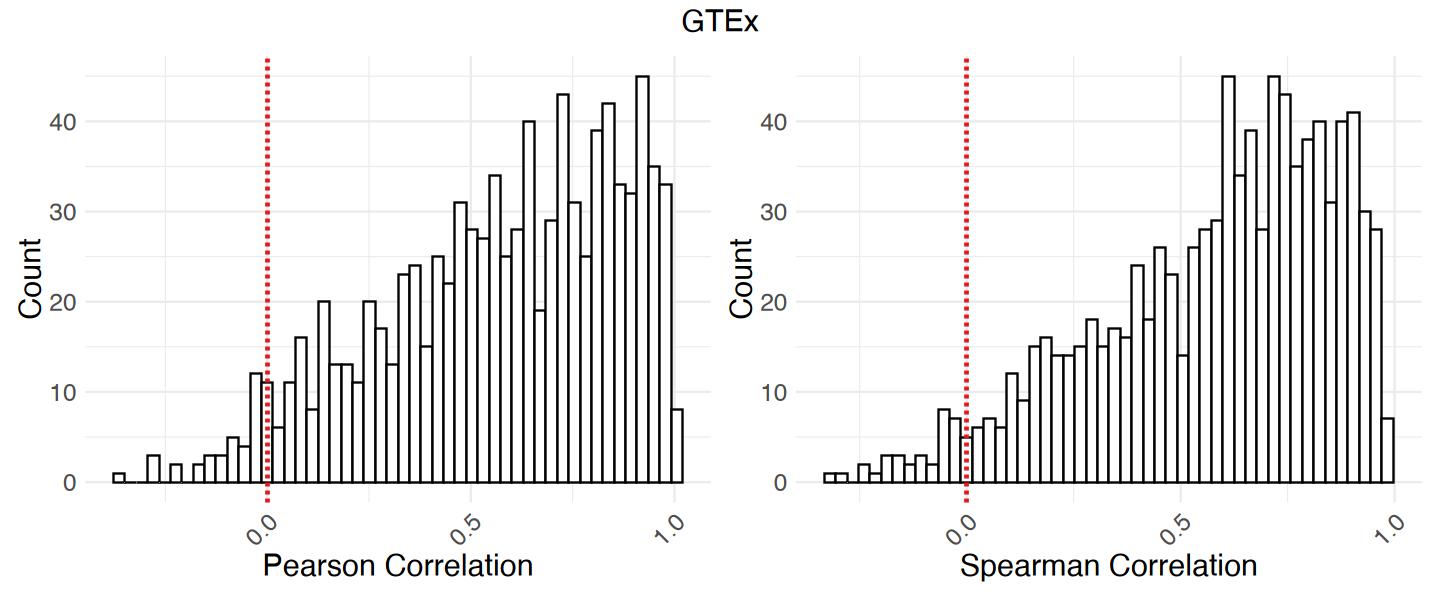

In [23]:
# Distribution of correlation values - Pearson and Spearman using ggplot2

# Pearson histogram
p1 <- ggplot(coexpression_results, aes(x = pearson_correlation)) +
     geom_histogram(bins = 50, fill = "white", color = "black") +
     geom_vline(xintercept = 0, color = red, linetype = "dashed", linewidth = 1) +
     labs(
          x = "Pearson Correlation",
          y = "Count"
     ) +
     theme_minimal() +
     theme(text = element_text(size = text_size),
            strip.text = element_text(size = text_size + 1),
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "bottom")

# Spearman histogram
p2 <- ggplot(coexpression_results, aes(x = spearman_correlation)) +
     geom_histogram(bins = 50, fill = "white", color = "black") +
     geom_vline(xintercept = 0, color = red, linetype = "dashed", linewidth = 1) +
     labs(
          x = "Spearman Correlation",
          y = "Count"
     ) +
     theme_minimal() +
     theme(text = element_text(size = text_size),
            strip.text = element_text(size = text_size + 1),
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "bottom")

# Visualize TF vs non-TF comparison without strand information
options(repr.plot.width=12, repr.plot.height=5)
# Combine plots
p_histogram <- p1 + p2 + plot_annotation(
     title = "GTEx",
     theme = theme(plot.title = element_text(hjust = 0.5, size = text_size))
)
p_histogram

In [24]:
# save the histogram
ggsave(filename = file.path(out_plot_dir, paste0("GTEx_histogram_", date, ".pdf")),
    plot = p_histogram, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_bin()`).”


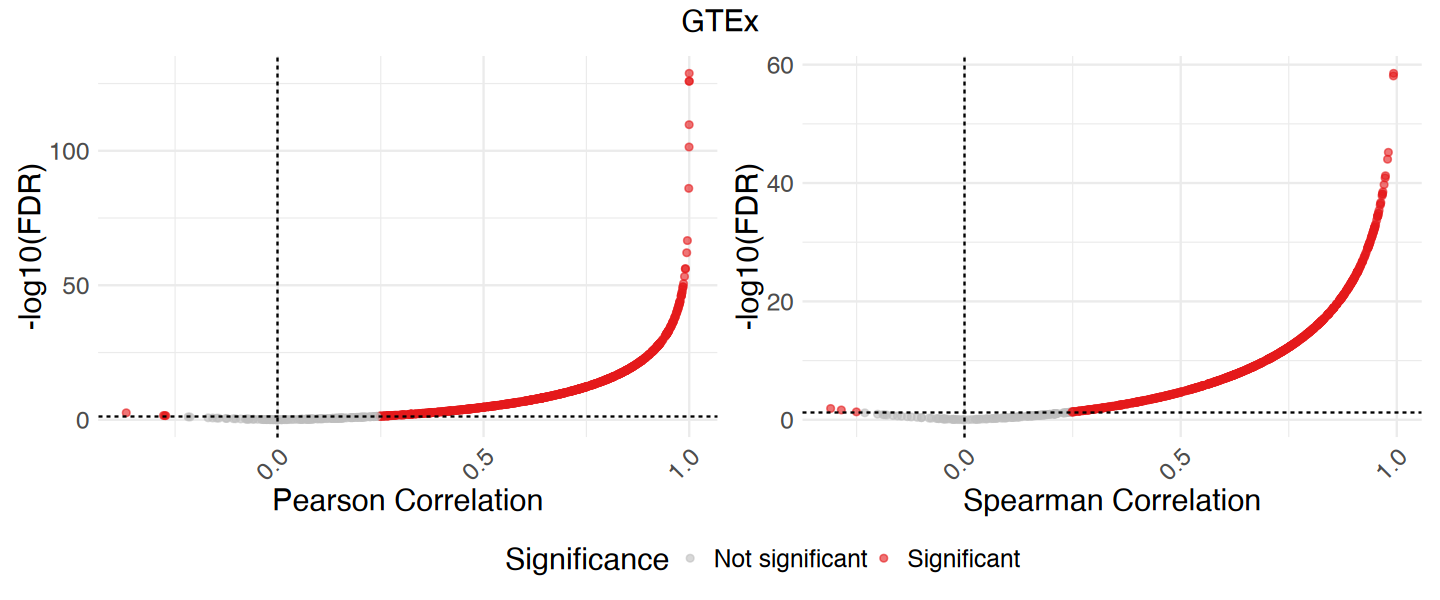

In [25]:
# Volcano plots: correlation vs -log10(FDR) for both Pearson and Spearman using ggplot2

# Prepare data for plotting
plot_data <- coexpression_results %>%
    mutate(
        pearson_log_fdr = -log10(pearson_fdr),
        spearman_log_fdr = -log10(spearman_fdr),
        pearson_color = ifelse(pearson_significant_0.05, "Significant", "Not significant"),
        spearman_color = ifelse(spearman_significant_0.05, "Significant", "Not significant")
    ) %>%
    filter(!is.na(pearson_log_fdr) & !is.na(spearman_log_fdr))

# Define color palette
color_palette <- c("Significant" = red, "Not significant" = "grey")

# Pearson volcano plot
p1 <- ggplot(plot_data, aes(x = pearson_correlation, y = pearson_log_fdr, color = pearson_color)) +
    geom_point(alpha = 0.6, size = 1.5) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
    scale_color_manual(values = color_palette, name = "Significance") +
    labs(
        x = "Pearson Correlation",
        y = "-log10(FDR)"
    ) +
    theme_minimal() +
    theme(
        text = element_text(size = text_size),
        strip.text = element_text(size = text_size + 1),
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

# Spearman volcano plot
p2 <- ggplot(plot_data, aes(x = spearman_correlation, y = spearman_log_fdr, color = spearman_color)) +
    geom_point(alpha = 0.6, size = 1.5) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
    scale_color_manual(values = color_palette, name = "Significance") +
    labs(
        x = "Spearman Correlation",
        y = "-log10(FDR)"
    ) +
    theme_minimal() +
    theme(
        text = element_text(size = text_size),
        strip.text = element_text(size = text_size + 1),
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

# Combine plots side by side
options(repr.plot.width=12, repr.plot.height=5)
p_volcano <- p1 + p2 + plot_layout(guides = "collect") + 
    plot_annotation(
        title = "GTEx",
        theme = theme(plot.title = element_text(hjust = 0.5, size = text_size))
    ) & theme(legend.position = "bottom")
p_volcano

In [26]:
# save the volcano plot
ggsave(filename = file.path(out_plot_dir, paste0("GTEx_volcano_", date, ".pdf")),
    plot = p_volcano, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`).”


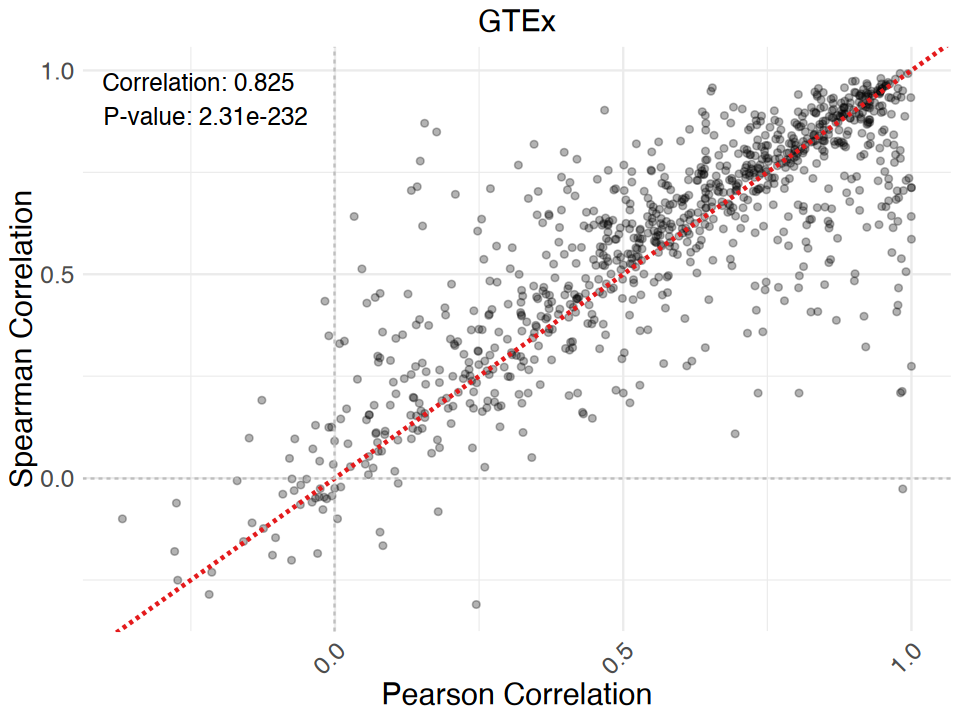

In [27]:
# Comparison: Pearson vs Spearman correlation

# Calculate correlation between the two methods
method_cor_test <- cor.test(coexpression_results$pearson_correlation, 
                            coexpression_results$spearman_correlation,
                            use = "complete.obs")
method_cor <- method_cor_test$estimate
method_pval <- method_cor_test$p.value
# Note: FDR adjustment not needed for single test (FDR = p-value)

options(repr.plot.width=8, repr.plot.height=6)
p_comparison_methods <-  ggplot(coexpression_results, aes(x = pearson_correlation, y = spearman_correlation)) +
    geom_point(alpha = 0.3, size = 1.5) +
    geom_abline(intercept = 0, slope = 1, color = red, linetype = "dashed", linewidth = 1) +
    geom_hline(yintercept = 0, color = "grey", linetype = "dashed") +
    geom_vline(xintercept = 0, color = "grey", linetype = "dashed") +
    annotate("text", x = -Inf, y = Inf, 
             label = paste0("Correlation: ", round(method_cor, 3), "\nP-value: ", format(method_pval, scientific = TRUE, digits = 3)),
             hjust = -0.1, vjust = 1.5, size = 5) +
    labs(
        x = "Pearson Correlation",
        y = "Spearman Correlation",
        title = "GTEx"
    ) +
    theme_minimal() +
    theme(
        text = element_text(size = text_size),
        strip.text = element_text(size = text_size + 1),
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(hjust = 0.5, size = text_size)
    )
p_comparison_methods

In [28]:
# save the volcano plot
ggsave(filename = file.path(out_plot_dir, paste0("GTEx_comparison_methods_", date, ".pdf")),
    plot = p_comparison_methods, 
    width = width * 0.3, height = 5.0, units = "in", dpi = dpi)

Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`).”
